## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os

from torch.nn import BatchNorm1d

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [2]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')
        
root_path = 'fmnist'
mkdir(root_path)

Directory fmnist already exists!


In [3]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path, 
                                                        train=True, 
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path, 
                                                       train=False, 
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

In [4]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [15]:
print(len(fmnist_dataset_train), len(fmnist_dataset_test))

60000 10000


In [6]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [7]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 1000),
            nn.ReLU(),
            nn.Linear(1000, 1000),
            nn.ReLU(),
            nn.Linear(1000, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [8]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 1000]         785,000
              ReLU-3                 [-1, 1000]               0
            Linear-4                 [-1, 1000]       1,001,000
              ReLU-5                 [-1, 1000]               0
            Linear-6                   [-1, 10]          10,010
Total params: 1,796,010
Trainable params: 1,796,010
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 6.85
Estimated Total Size (MB): 6.89
----------------------------------------------------------------


Your experiments come here:

100%|██████████| 200/200 [57:27<00:00, 17.24s/it]


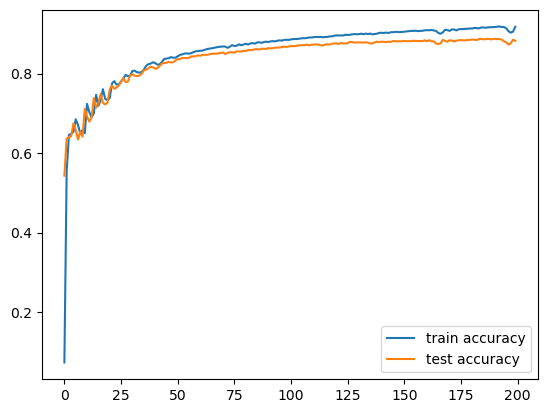

In [17]:
from tqdm.auto import tqdm
batch_size = 60000
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2)
model = TinyNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters()) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE
train_accs = []
test_accs = []
# Your experiments, training and validation loops here
for epoch in tqdm(range(200)):
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = loss_func(outputs, labels)
        opt.zero_grad()
        loss.backward()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        opt.step()
    train_accs.append(correct/total)
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    test_accs.append(correct/total)

plt.plot(train_accs, label='train accuracy')
plt.plot(test_accs, label='test accuracy')
plt.legend()

### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [25]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 5000),
            nn.ReLU(),
            nn.Linear(5000, 1000),
            nn.ReLU(),
            nn.Linear(1000, 200),
            nn.ReLU(),
            nn.Linear(200, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [26]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 5000]       3,925,000
              ReLU-3                 [-1, 5000]               0
            Linear-4                 [-1, 1000]       5,001,000
              ReLU-5                 [-1, 1000]               0
            Linear-6                  [-1, 200]         200,200
              ReLU-7                  [-1, 200]               0
            Linear-8                   [-1, 10]           2,010
Total params: 9,128,210
Trainable params: 9,128,210
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.10
Params size (MB): 34.82
Estimated Total Size (MB): 34.93
----------------------------------------------------------------


In [28]:
from tqdm import tqdm
batch_size = 10000
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2)
model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters()) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, training and validation loops here
for epoch in range(20):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = loss_func(outputs, labels)
        opt.zero_grad()
        loss.backward()
        running_loss += loss.item()
        opt.step()
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f"Epoch {epoch}, accuracy on test: {100 * correct/total:.2f}%")

Epoch 0, accuracy on test: 58.91%
Epoch 1, accuracy on test: 72.45%
Epoch 2, accuracy on test: 75.51%
Epoch 3, accuracy on test: 79.31%
Epoch 4, accuracy on test: 81.41%
Epoch 5, accuracy on test: 82.45%
Epoch 6, accuracy on test: 82.68%
Epoch 7, accuracy on test: 84.16%
Epoch 8, accuracy on test: 84.77%
Epoch 9, accuracy on test: 85.13%
Epoch 10, accuracy on test: 85.65%
Epoch 11, accuracy on test: 86.25%
Epoch 12, accuracy on test: 86.26%
Epoch 13, accuracy on test: 86.56%
Epoch 14, accuracy on test: 87.09%
Epoch 15, accuracy on test: 86.98%
Epoch 16, accuracy on test: 87.22%
Epoch 17, accuracy on test: 87.97%
Epoch 18, accuracy on test: 87.99%
Epoch 19, accuracy on test: 87.27%


### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results. 

In [29]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here
            nn.Linear(input_shape, 5000),
            nn.BatchNorm1d(5000),
            nn.ReLU(),
            nn.Linear(5000, 1000),
            nn.BatchNorm1d(1000),
            nn.ReLU(),
            nn.Linear(1000, 200),
            nn.BatchNorm1d(200),
            nn.ReLU(),
            nn.Linear(200, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [30]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 5000]       3,925,000
       BatchNorm1d-3                 [-1, 5000]          10,000
              ReLU-4                 [-1, 5000]               0
            Linear-5                 [-1, 1000]       5,001,000
       BatchNorm1d-6                 [-1, 1000]           2,000
              ReLU-7                 [-1, 1000]               0
            Linear-8                  [-1, 200]         200,200
       BatchNorm1d-9                  [-1, 200]             400
             ReLU-10                  [-1, 200]               0
           Linear-11                   [-1, 10]           2,010
Total params: 9,140,610
Trainable params: 9,140,610
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

In [31]:
from tqdm import tqdm
batch_size = 10000
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2)
model = FixedNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters()) # YOUR CODE HERE
loss_func = nn.CrossEntropyLoss() # YOUR CODE HERE

# Your experiments, training and validation loops here
for epoch in range(20):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = loss_func(outputs, labels)
        opt.zero_grad()
        loss.backward()
        running_loss += loss.item()
        opt.step()
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f"Epoch {epoch}, accuracy on test: {100 * correct/total:.2f}%")

Epoch 0, accuracy on test: 79.31%
Epoch 1, accuracy on test: 82.59%
Epoch 2, accuracy on test: 84.42%
Epoch 3, accuracy on test: 86.04%
Epoch 4, accuracy on test: 86.88%
Epoch 5, accuracy on test: 87.21%
Epoch 6, accuracy on test: 87.66%
Epoch 7, accuracy on test: 88.04%
Epoch 8, accuracy on test: 87.81%
Epoch 9, accuracy on test: 88.40%
Epoch 10, accuracy on test: 88.64%
Epoch 11, accuracy on test: 89.12%
Epoch 12, accuracy on test: 88.39%
Epoch 13, accuracy on test: 88.84%
Epoch 14, accuracy on test: 89.13%
Epoch 15, accuracy on test: 89.08%
Epoch 16, accuracy on test: 89.15%
Epoch 17, accuracy on test: 88.90%
Epoch 18, accuracy on test: 88.83%
Epoch 19, accuracy on test: 88.94%


### Conclusions:
_Write down small report with your conclusions and your ideas._

Well... Adding Batch norm to the model improved overall performance!